Session Data (partial): ID=1, DataFileName=SessionsData/TypingSessions/ddf13c3b-6e60-495b-aa02-23106e6846c7.pcm, StartKeyID=1, EndKeyID=18, BrowserOffset=1755540801477
[INFO] Detecting sync tone to align audio...


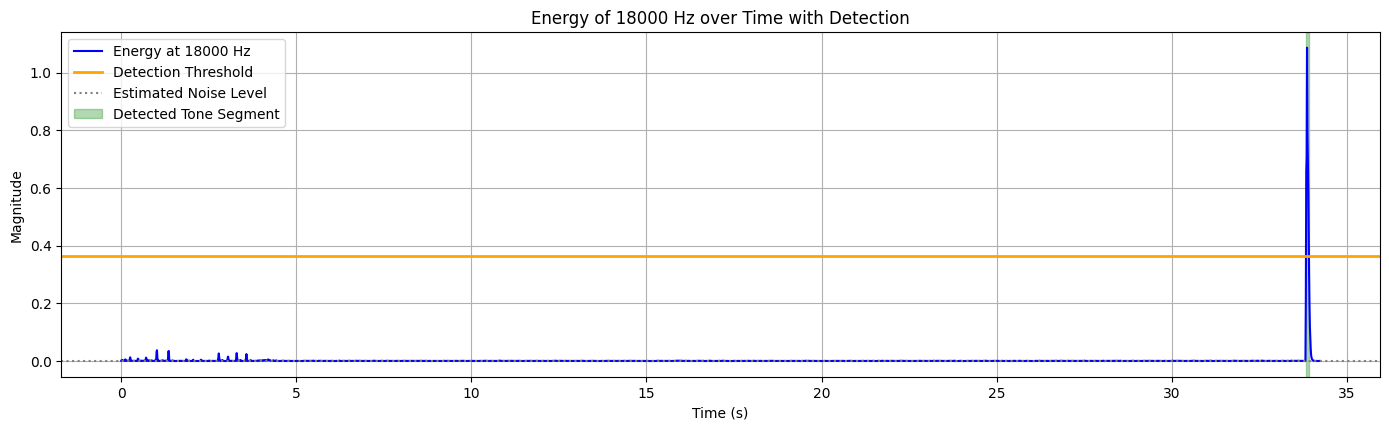

Detected sync tone from 33843.08 ms to 33912.74 ms
first_keypress_timestamp: 1755540767505
start_tone_browser_time: 33972
offset: 128.9160997732397
start time from browser: 1755540801477
[(621, 7456, 'h', 2), (4193, 11778, 'i', 3), (10631, 16012, 's', 4), (20113, 25317, ' ', 5), (30653, 35812, 'i', 6), (37709, 43221, 's', 7), (43883, 50454, ' ', 8), (51468, 56098, 'a', 9), (58833, 64610, ' ', 10), (81235, 86086, 't', 11), (89791, 93936, 'e', 12), (99713, 103859, 's', 13), (110209, 114707, 't', 14), (121896, 127364, ' ', 15), (133759, 139403, ' ', 16), (144607, 150252, ' ', 17), (156911, 162953, ' ', 18)]


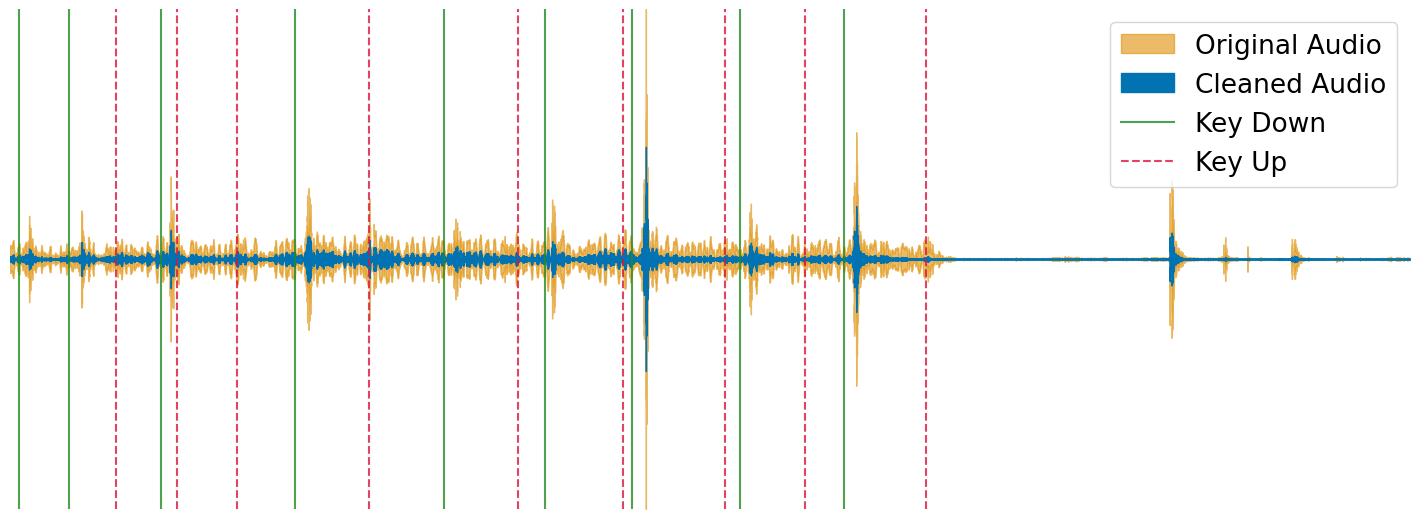

In [44]:
#this is the new one that works
# %matplotlib ipympl
import sqlite3
import librosa, os
import soundfile as sf
import matplotlib.pyplot as plt
import noisereduce as nr
import numpy as np
from DBConfig import DB_HOST, DB_NAME, DB_PASSWORD, DB_PORT, DB_USER, psycopg2



def timestamp_to_sample(timestamp_ms, sr):
    return int(timestamp_ms * sr / 1000)




def AdjustKeypressTimestamps(keypresses, start_timestamp, y, sr, trim_ms=60):
    """Returns array of (start_sample, end_sample, key, key_id)"""
    return [
    (timestamp_to_sample(start - start_timestamp - 10, sr), 
     timestamp_to_sample(end - start_timestamp + 25, sr), 
     key,
     key_id)
    for start, end, key, key_id in keypresses
    if (start - start_timestamp - 10) >= 0
    ]
    
    




def TrimAudioFromBeginning(trim_ms):
    # --- Trim the first 60 ms of audio ---
    # param is Time to remove from the start (in ms)
    trim_samples = int(trim_ms * sr / 1000)  # Convert ms to samples

    # Remove the first 60 ms from the audio
    y_trimmed = y[trim_samples:]  # New audio starts after 60 ms

    # Update audio duration (now shorter by 60 ms)
    audio_duration_ms = len(y_trimmed) * 1000 / sr
    return y_trimmed


def save_keystroke_audio(keypress_samples, y, sr, session_id):
    os.makedirs(f"SessionsData/KeystrokeData/session_{session_id}", exist_ok=True)
        
    # Re-establish database connection
    conn = psycopg2.connect(
        dbname=DB_NAME,
        user=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        port=DB_PORT
    )
    cursor = conn.cursor()
    
    for start, end, key, key_id in keypress_samples:
        if key == '/':
            key = 'Forward slash'
        segment = y[start:end]
        filename = f"key_{key_id}_{key}.wav"
        filepath = f"SessionsData/KeystrokeData/session_{session_id}/{filename}"
        sf.write(filepath, segment, sr, subtype='PCM_16')
        print(filepath)
        # Update database
        cursor.execute("""
            UPDATE "KeyPresses"
            SET "AudioFileName" = %s
            WHERE "KeyID" = %s
        """, (filepath, key_id))
    
    conn.commit()
    conn.close()
    

def detect_sync_tone(y, sr, target_freq=4400, threshold_ratio=5.0):
    """
    Detects the start and end times of a sync tone at a target frequency within the audio.

    Args:
        y (np.ndarray): Audio time series.
        sr (int): Sampling rate of `y`.
        target_freq (float): The frequency of the sync tone to detect (in Hz).
        threshold_ratio (float): Multiplier for the noise level to determine the detection threshold.
                                 A higher ratio means a stricter detection.

    Returns:
        tuple: A tuple (start_time_ms, end_time_ms) representing the start and end
               times of the longest detected sync tone segment in milliseconds.
               Returns (None, None) if no tone is detected.
    """
    # Define n_fft and hop_length explicitly for consistency with librosa's defaults
    # These are the default values used by librosa.stft, essential for frame-to-time conversion.
    n_fft = 2048
    hop_length = 512

    # 1. Perform Short-Time Fourier Transform (STFT)
    # D will have shape (1 + n_fft/2, num_frames)
    D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
    magnitudes = np.abs(D) # Get the magnitude spectrogram

    # 2. Identify the target frequency bin
    # Get the frequencies corresponding to each STFT bin
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    # Find the index of the frequency bin closest to the target frequency
    target_freq_idx = np.argmin(np.abs(freqs - target_freq))

    # 3. Extract the magnitude spectrum for the target frequency across all time frames
    # This gives us the energy of the target frequency over time.
    target_energy = magnitudes[target_freq_idx, :]

    # 4. Calculate a noise/background level
    # Using the median is robust as it's less affected by outliers (like the tone itself).
    noise_level = np.median(target_energy)

    # 5. Determine a threshold for tone detection
    # The tone must be significantly louder than the background noise to be detected.
    threshold = noise_level * threshold_ratio

    # 6. Detect tone presence (create a boolean array where True indicates tone presence)
    tone_present = target_energy > threshold

    # the code below is to visualize when the tone was detected in the audio
    plt.figure(figsize=(14, 8))

    

    # Subplot 2: Energy at target frequency over time
    plt.subplot(2, 1, 1)
    times = librosa.frames_to_time(np.arange(len(target_energy)), sr=sr, hop_length=hop_length)
    plt.plot(times, target_energy, label=f'Energy at {target_freq} Hz', color='blue')
    plt.axhline(y=threshold, color='orange', linestyle='-', linewidth=2, label='Detection Threshold')
    plt.axhline(y=noise_level, color='gray', linestyle=':', linewidth=1.5, label='Estimated Noise Level')

    # Highlight detected tone segments
    # Re-calculating segments for plotting to ensure independent logic
    plot_segments = []
    current_start_frame_plot = -1
    for i, is_present in enumerate(tone_present):
        if is_present and current_start_frame_plot == -1:
            current_start_frame_plot = i
        elif not is_present and current_start_frame_plot != -1:
            plot_segments.append((current_start_frame_plot, i - 1))
            current_start_frame_plot = -1
    if current_start_frame_plot != -1:
        plot_segments.append((current_start_frame_plot, len(tone_present) - 1))

    for seg_start_frame, seg_end_frame in plot_segments:
        seg_start_time = librosa.frames_to_time(seg_start_frame, sr=sr, hop_length=hop_length)
        seg_end_time = librosa.frames_to_time(seg_end_frame, sr=sr, hop_length=hop_length)
        plt.axvspan(seg_start_time, seg_end_time, color='green', alpha=0.3, label='Detected Tone Segment' if seg_start_frame == plot_segments[0][0] else "")

    plt.title(f'Energy of {target_freq} Hz over Time with Detection')
    plt.xlabel('Time (s)')
    plt.ylabel('Magnitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    # --- End Plotting ---
    # If no part of the audio exceeds the threshold, no tone is detected
    if not np.any(tone_present):
        print(f"No sync tone detected above threshold (threshold={threshold:.2f}). Max energy at {target_freq}Hz: {np.max(target_energy):.2f}")
        return None, None

    # 7. Find contiguous segments of tone presence
    segments = []
    current_start_frame = -1

    # Iterate through the boolean array to find start and end frames of continuous True blocks
    for i, is_present in enumerate(tone_present):
        if is_present and current_start_frame == -1:
            # Tone starts here
            current_start_frame = i
        elif not is_present and current_start_frame != -1:
            # Tone ends here
            segments.append((current_start_frame, i - 1))
            current_start_frame = -1
    
    # Handle the case where the tone extends to the very end of the audio
    if current_start_frame != -1:
        segments.append((current_start_frame, len(tone_present) - 1))

    # If somehow no segments were found despite np.any(tone_present) being true (e.g., single frame),
    # this check handles it.
    if not segments:
        print("Error: Tone present but no continuous segments found after processing.")
        return None, None

    # 8. Find the longest segment (assuming the sync tone is the most prominent/longest one)
    longest_segment = max(segments, key=lambda s: s[1] - s[0])
    start_frame, end_frame = longest_segment

    # 9. Convert frames (STFT time bins) to actual time in milliseconds
    start_time_ms = librosa.frames_to_time(start_frame, sr=sr, hop_length=hop_length) * 1000
    end_time_ms = librosa.frames_to_time(end_frame, sr=sr, hop_length=hop_length) * 1000

    return start_time_ms, end_time_ms





# Step 2: Query the session data
session_id = "1"  # Replace with your session ID
conn = psycopg2.connect(
    dbname=DB_NAME,
    user=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT
)
cursor = conn.cursor()

# Step 2: Query the session data - SELECTING ONLY USED COLUMNS
# Used: ID, DataFileName, StartKeyID, EndKeyID, BrowserOffset
session_query = """
SELECT "ID", "DataFileName", "StartKeyID", "EndKeyID", "BrowserOffset"
FROM "Sessions"
WHERE "ID" = %s
"""
cursor.execute(session_query, (session_id,))
session_data = cursor.fetchone()

if session_data:
    # Unpack only the 5 columns retrieved
    session_id_db, data_file_name, start_key_id, end_key_id, browser_offset = session_data
    
    print(f"Session Data (partial): ID={session_id_db}, DataFileName={data_file_name}, StartKeyID={start_key_id}, EndKeyID={end_key_id}, BrowserOffset={browser_offset}")
else:
    raise ValueError(f"Session with ID {session_id} not found.")


# Step 3: Query the keypress data for the session
keypress_query = """
SELECT "KeyDownTimestamp", "KeyUpTimestamp", "KeyPressed", "KeyID"
FROM "KeyPresses"
WHERE "KeyID" BETWEEN %s AND %s
ORDER BY "KeyDownTimestamp"
"""
cursor.execute(keypress_query, (start_key_id, end_key_id,))
keypresses = cursor.fetchall()

# Close the database connection
conn.close()

# Step 4: Load the audio file
audio_path = f"{data_file_name}.wav"  # Use the DataFileName from the session data
# Load audio
y, sr = librosa.load(audio_path, sr=None)

trim_ms = 80

y_trimmed = TrimAudioFromBeginning(trim_ms)

print("[INFO] Detecting sync tone to align audio...")
# Call the implemented detect_sync_tone function
start_tone_ms, end_tone_ms = detect_sync_tone(y_trimmed, sr, target_freq=18000, threshold_ratio=800.0)

if start_tone_ms is None or end_tone_ms is None:
    raise RuntimeError("Could not detect sync tone. Cannot align keystrokes without it.")

print(f"Detected sync tone from {start_tone_ms:.2f} ms to {end_tone_ms:.2f} ms")



first_keypress_timestamp = keypresses[0][0]
start_tone_browser_time = browser_offset - first_keypress_timestamp
offset = start_tone_browser_time - start_tone_ms

print(f"first_keypress_timestamp: {first_keypress_timestamp}")
print(f"start_tone_browser_time: {start_tone_browser_time}")
print(f"offset: {offset}")
# print(f"start time from watch: {start_timestamp}")
print(f"start time from browser: {browser_offset}")



# Aligning the keypress timings with the audio file
keypress_samples = AdjustKeypressTimestamps(keypresses, first_keypress_timestamp + offset + trim_ms , len(y_trimmed), sr)


# audio_start_time = start_timestamp + trim_ms + (browser_offset - start_timestamp - start_tone_ms)
# #aligning the keystroke timings with the audio file
# keypress_samples = AdjustKeypressTimestamps(keypresses, audio_start_time , y_trimmed, sr, trim_ms)



'''cleaning the audio'''
# Step 8: (Optional) Apply noise reduction
# noise_profile = y[-int(8.5 * sr):]  # Use the last 8500 ms as the noise profile 8.5 seconds
# y_cleaned = nr.reduce_noise(y=y_trimmed, y_noise=noise_profile, sr=sr)
print(keypress_samples)
#extracting and saving the keystroker data from the audio file
# save_keystroke_audio(keypress_samples, y_trimmed, sr, session_id)




# --- trim the last 4.5 seconds for plotting ---
end_trim_s = 32
end_trim_samples = int(end_trim_s * sr)        # number of samples to drop


# take everything except the last 4.5 s
# Step 8: (Optional) Apply noise reduction
noise_profile = y[-int(8.5 * sr):]  # Use the last 500 ms as the noise profile
y_cleaned = nr.reduce_noise(y=y_trimmed, y_noise=noise_profile, sr=sr)
y_plot_cleaned = y_cleaned[:-end_trim_samples]
y_plot = y_trimmed[:-end_trim_samples]


first_start = True
first_end = True
# Plotting
plt.figure(figsize=(14, 5))
ax = plt.gca() # Get the current axes object for more control
# librosa.display.waveshow(y_trimmed, sr=sr, alpha=1, color='#DE8F05')
librosa.display.waveshow(y_plot, sr=sr, alpha=0.6, color='#DE8F05', label='Original Audio')
librosa.display.waveshow(y_plot_cleaned, sr=sr, ax=ax, alpha=1, color='#0173B2', label='Cleaned Audio')


for start, end, key, _ in keypress_samples[:9]:
#     # Ensure keypresses are within the plotted range before drawing
    if start < len(y_trimmed) and end < len(y_trimmed):
        plt.axvline(start/sr, color='#228B22', alpha=0.8, linestyle='-', linewidth=1.5, label='Key Down' if start == keypress_samples[0][0] else "")
        plt.axvline(end/sr, color='#DC143C', alpha=0.8, linestyle='--', linewidth=1.5, label='Key Up' if end == keypress_samples[0][1] else "")

        # Adjust text vertical position dynamically based on y_plot's amplitude range
        # y_text_pos = np.max(np.abs(y_plot)) * 0.8 # 80% of max amplitude for text position
        # plt.text((start + end)/2/sr, y_text_pos, key, ha='center', va='top', fontsize=9, color='blue')
# plt.axvline(((start_tone_ms) * sr / 1000)/sr, color='b', alpha=0.5)
# plt.axvline((end_tone_ms * sr / 1000)/sr, color='b', alpha=0.5)
# plt.title(f'Audio Waveform with Aligned Keystrokes (Session {session_id})')
# plt.xlabel('Time (s)')
# plt.ylabel('Amplitude')
plt.legend(fontsize=19)
# plt.ylim(-0.3, 0.3)  
plt.margins(0)  # Remove default margins
plt.subplots_adjust(left=0, bottom=0, right=1, top=1)  # Remove padding around subplot



ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")
# ax.legend().remove()
# Hide ticks, labels, and frame
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout(pad=0)
plt.savefig("Cleaned Aligning Keystrokes Without Tone.pdf", format="pdf", dpi=300, transparent=True)
plt.show() # This will now display the interactive plot within the notebook


In [1]:
1

1

In [ ]:
'''
I tried to correlate the latency timestamp between the watch and the watch server and the browser and 
the web server but it was a mess and it didn't work. so I correlated the keystrokes to the audio 
device based on the end and analyzed the data to identify the noise and keystroke activity and
reduced the noise using the spectral gating algorithm

so when the user stops typing for 1 second the recording stops on the watch, so I use that
to align the keystrokes with the audio file starting from the last keystroke.


analyzed some of the data 

explain how the noise cancelling works in detail
'''

158

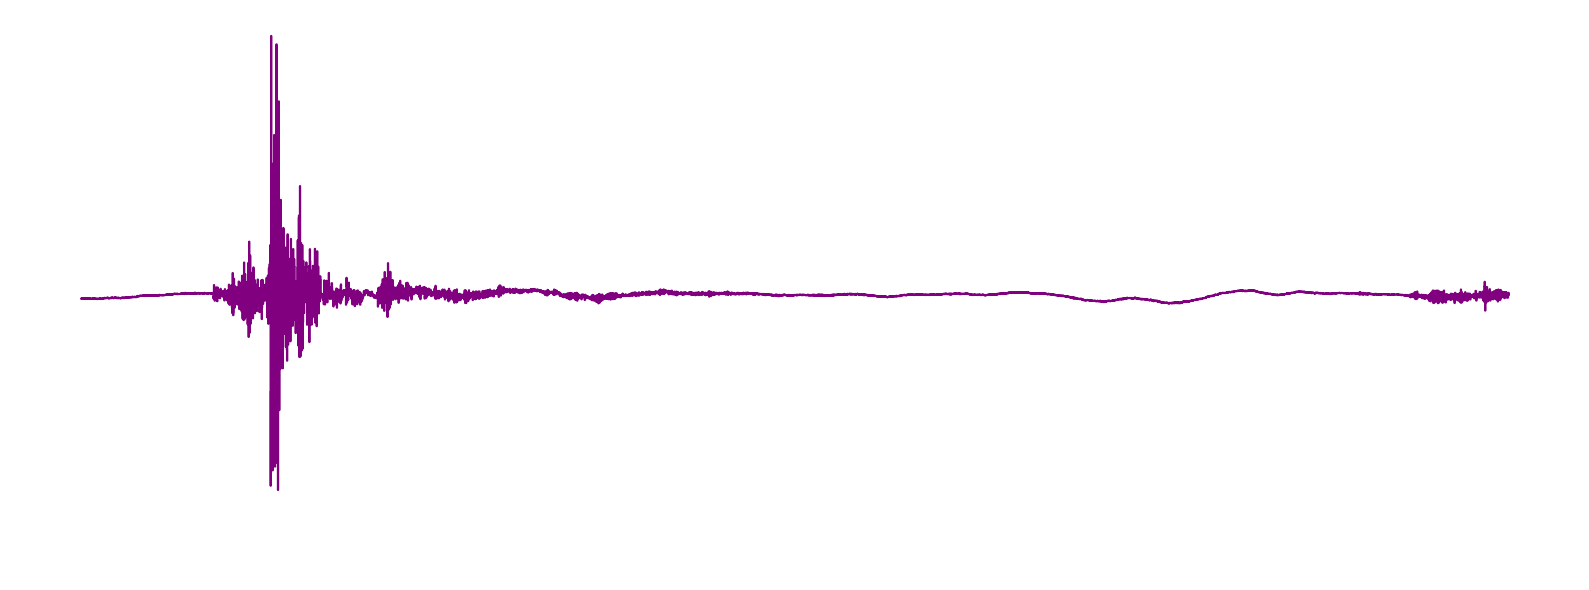

In [7]:
import librosa, matplotlib.pyplot as plt


file = "SessionsData/KeystrokeData/session_1/key_16_ .wav"

y, sr = librosa.load(file, sr=None)
plt.figure(figsize=(16, 6))

ax = plt.gca()
librosa.display.waveshow(y, sr=sr,ax=ax, color='purple', label='Original Audio')

ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("Single Keystroke.svg", format="svg", dpi=300, transparent=True)

# 1. Waveforms
# plt.show()